In [1]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install tensorflow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [63]:
DATASET_PATH = r"C:\deep learning for medical imaging\busi dataset\Dataset_BUSI_with_GT"

classes = ["benign","malignant","normal"]

IMG_SIZE = 224

images = []
labels = []

In [64]:
for c in classes:

    path = os.path.join(DATASET_PATH,c)

    for img in os.listdir(path):

        if "_mask" in img:
            continue

        img_path = os.path.join(path,img)

        image = cv2.imread(img_path)

        image = cv2.resize(image,(IMG_SIZE,IMG_SIZE))

        image = image/255.0

        images.append(image)

        labels.append(c)

X = np.array(images)
y = np.array(labels)

print("Dataset shape:",X.shape)

Dataset shape: (780, 224, 224, 3)


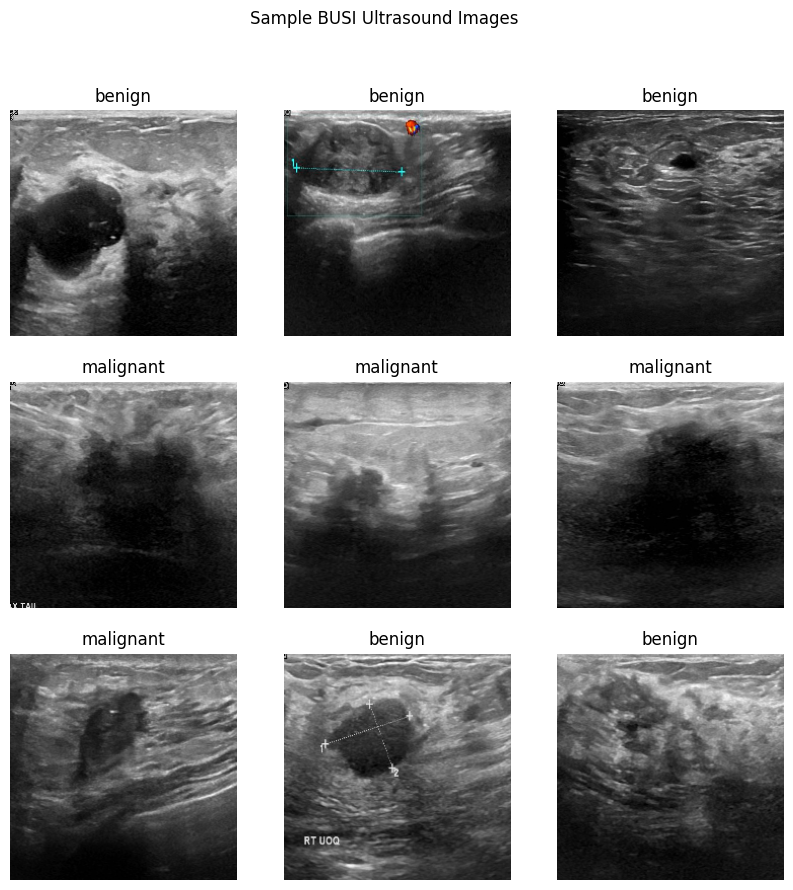

In [65]:
plt.figure(figsize=(10,10))

for i in range(9):

    idx = random.randint(0,len(X)-1)

    plt.subplot(3,3,i+1)

    plt.imshow(X[idx])

    plt.title(labels[idx])

    plt.axis("off")

plt.suptitle("Sample BUSI Ultrasound Images")

plt.show()

In [66]:
le = LabelEncoder()

y = le.fit_transform(y)

print("Classes:",le.classes_)

Classes: ['benign' 'malignant' 'normal']


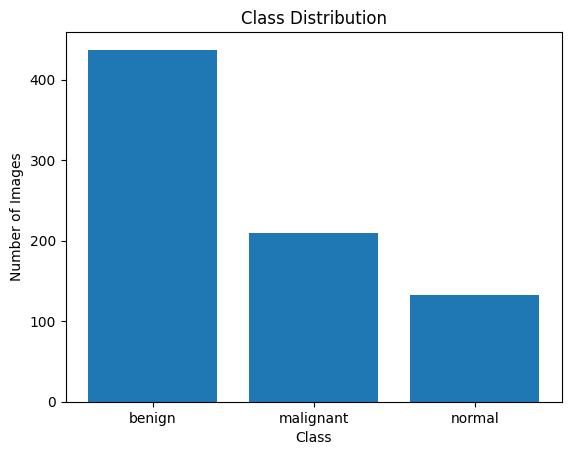

In [67]:
unique,counts = np.unique(y,return_counts=True)

plt.bar(le.classes_,counts)

plt.title("Class Distribution")

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.show()

In [68]:
X_train,X_temp,y_train,y_temp = train_test_split(
    X,y,test_size=0.30,stratify=y,random_state=42
)

X_val,X_test,y_val,y_test = train_test_split(
    X_temp,y_temp,test_size=0.50,stratify=y_temp,random_state=42
)

print("Train:",X_train.shape)
print("Validation:",X_val.shape)
print("Test:",X_test.shape)

Train: (546, 224, 224, 3)
Validation: (117, 224, 224, 3)
Test: (117, 224, 224, 3)


In [69]:
def create_model():

    base_model = EfficientNetB0(
        input_shape=(224,224,3),
        include_top=False,
        weights="imagenet"
    )

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output

    x = GlobalAveragePooling2D()(x)

    x = Dense(256,activation="relu")(x)

    x = Dropout(0.5)(x)

    output = Dense(3,activation="softmax")(x)

    model = Model(inputs=base_model.input,outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0003),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [70]:
model_base = create_model()

history_base = model_base.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=25,
    batch_size=16
)

Epoch 1/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 16s 321ms/step - accuracy: 0.5421 - loss: 1.0194 - val_accuracy: 0.5556 - val_loss: 0.9836
Epoch 2/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.5586 - loss: 1.0175 - val_accuracy: 0.5556 - val_loss: 0.9871
Epoch 3/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 289ms/step - accuracy: 0.5641 - loss: 0.9828 - val_accuracy: 0.5556 - val_loss: 0.9909
Epoch 4/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 286ms/step - accuracy: 0.5531 - loss: 1.0128 - val_accuracy: 0.5556 - val_loss: 0.9836
Epoch 5/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 282ms/step - accuracy: 0.5641 - loss: 0.9983 - val_accuracy: 0.5556 - val_loss: 0.9835
Epoch 6/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 284ms/step - accuracy: 0.5513 - loss: 1.0127 - val_accuracy: 0.5556 - val_loss: 0.9887
Epoch 7/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 320ms/step - accuracy: 0.5586 - loss: 0.9861 - val_accuracy: 0.5556 - val_loss: 0.9978
Epoch 8/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 294ms/step - accuracy: 0.5604 - loss: 1.0106 - val_accu

In [74]:
pred = model_base.predict(X_test)

pred_classes = np.argmax(pred,axis=1)

acc1 = accuracy_score(y_test,pred_classes)
prec1 = precision_score(y_test,pred_classes,average="weighted")
rec1 = recall_score(y_test,pred_classes,average="weighted")
f11 = f1_score(y_test,pred_classes,average="weighted")

print("BASELINE RESULTS")
print("Accuracy:",acc1)
print("Precision:",prec1)
print("Recall:",rec1)
print("F1:",f11)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 307ms/step
BASELINE RESULTS
Accuracy: 0.5641025641025641
Precision: 0.31821170282708744
Recall: 0.5641025641025641
F1: 0.40689365279529216


c:\Users\venka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [75]:
X_train_flat = X_train.reshape(X_train.shape[0],-1)

smote = SMOTE(random_state=42)

X_smote,y_smote = smote.fit_resample(X_train_flat,y_train)

X_smote = X_smote.reshape(-1,224,224,3)

print("SMOTE dataset:",X_smote.shape)

SMOTE dataset: (918, 224, 224, 3)


In [76]:
model_smote = create_model()

history_smote = model_smote.fit(
    X_smote,
    y_smote,
    validation_data=(X_val,y_val),
    epochs=25,
    batch_size=16
)

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 27s 326ms/step - accuracy: 0.3257 - loss: 1.1269 - val_accuracy: 0.2735 - val_loss: 1.1113
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 307ms/step - accuracy: 0.3312 - loss: 1.1175 - val_accuracy: 0.2735 - val_loss: 1.1003
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 344ms/step - accuracy: 0.3126 - loss: 1.1160 - val_accuracy: 0.1709 - val_loss: 1.1813
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 331ms/step - accuracy: 0.3268 - loss: 1.1106 - val_accuracy: 0.5556 - val_loss: 1.0821
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 342ms/step - accuracy: 0.3246 - loss: 1.1046 - val_accuracy: 0.2735 - val_loss: 1.1304
Epoch 6/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 319ms/step - accuracy: 0.3540 - loss: 1.1017 - val_accuracy: 0.2735 - val_loss: 1.1015
Epoch 7/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 325ms/step - accuracy: 0.3181 - loss: 1.1026 - val_accuracy: 0.1709 - val_loss: 1.1038
Epoch 8/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 339ms/step - accuracy: 0.3355 - loss: 1.1000 - val_accu

In [77]:
model_smote = create_model()

history_smote = model_smote.fit(
    X_smote,
    y_smote,
    validation_data=(X_val,y_val),
    epochs=25,
    batch_size=16
)

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 37s 542ms/step - accuracy: 0.2974 - loss: 1.1424 - val_accuracy: 0.5556 - val_loss: 1.0850
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 36s 623ms/step - accuracy: 0.3464 - loss: 1.1178 - val_accuracy: 0.2735 - val_loss: 1.1546
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 36s 624ms/step - accuracy: 0.3301 - loss: 1.1139 - val_accuracy: 0.2735 - val_loss: 1.0828
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 37s 635ms/step - accuracy: 0.3017 - loss: 1.1181 - val_accuracy: 0.2735 - val_loss: 1.0967
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 30s 511ms/step - accuracy: 0.3203 - loss: 1.1049 - val_accuracy: 0.1709 - val_loss: 1.1309
Epoch 6/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 268ms/step - accuracy: 0.3420 - loss: 1.1007 - val_accuracy: 0.5556 - val_loss: 1.0959
Epoch 7/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 295ms/step - accuracy: 0.3105 - loss: 1.1035 - val_accuracy: 0.5556 - val_loss: 1.0957
Epoch 8/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 273ms/step - accuracy: 0.3094 - loss: 1.1028 - val_accu

In [78]:
pred = model_smote.predict(X_test)

pred_classes = np.argmax(pred,axis=1)

acc2 = accuracy_score(y_test,pred_classes)
prec2 = precision_score(y_test,pred_classes,average="weighted")
rec2 = recall_score(y_test,pred_classes,average="weighted")
f12 = f1_score(y_test,pred_classes,average="weighted")

print("SMOTE RESULTS")
print(acc2,prec2,rec2,f12)

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step  
SMOTE RESULTS
0.26495726495726496 0.0702023522536343 0.26495726495726496 0.11099561099561099


c:\Users\venka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [79]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.5947712418300654), 1: np.float64(1.2380952380952381), 2: np.float64(1.956989247311828)}


In [80]:
model_classweight = create_model()

history_classweight = model_classweight.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=25,
    batch_size=16,
    class_weight=class_weights
)

Epoch 1/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 368ms/step - accuracy: 0.3150 - loss: 1.1583 - val_accuracy: 0.5556 - val_loss: 1.0201
Epoch 2/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 368ms/step - accuracy: 0.3352 - loss: 1.1151 - val_accuracy: 0.5556 - val_loss: 1.0710
Epoch 3/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 341ms/step - accuracy: 0.3315 - loss: 1.1239 - val_accuracy: 0.5556 - val_loss: 1.0418
Epoch 4/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 345ms/step - accuracy: 0.3168 - loss: 1.1355 - val_accuracy: 0.5556 - val_loss: 1.0564
Epoch 5/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 342ms/step - accuracy: 0.4048 - loss: 1.1182 - val_accuracy: 0.2735 - val_loss: 1.1281
Epoch 6/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 349ms/step - accuracy: 0.3956 - loss: 1.1143 - val_accuracy: 0.1709 - val_loss: 1.1214
Epoch 7/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 351ms/step - accuracy: 0.2912 - loss: 1.1053 - val_accuracy: 0.2735 - val_loss: 1.0999
Epoch 8/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 615ms/step - accuracy: 0.2399 - loss: 1.1052 - val_accu

In [81]:
pred = model_classweight.predict(X_test)

pred_classes = np.argmax(pred,axis=1)

acc3 = accuracy_score(y_test,pred_classes)
prec3 = precision_score(y_test,pred_classes,average="weighted")
rec3 = recall_score(y_test,pred_classes,average="weighted")
f13 = f1_score(y_test,pred_classes,average="weighted")

print("CLASS WEIGHT RESULTS")
print(acc3,prec3,rec3,f13)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 868ms/step
CLASS WEIGHT RESULTS
0.5641025641025641 0.31821170282708744 0.5641025641025641 0.40689365279529216


c:\Users\venka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [82]:
datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

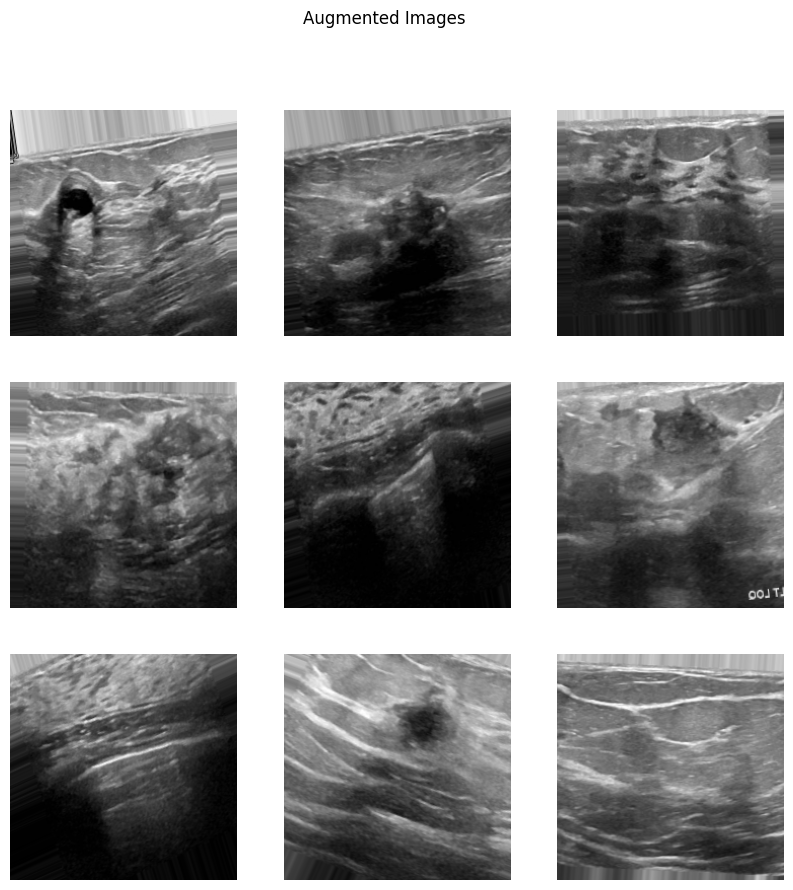

In [83]:
batch = datagen.flow(X_train,y_train,batch_size=9)

images_batch,labels_batch = next(batch)

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images_batch[i])

    plt.axis("off")

plt.suptitle("Augmented Images")

plt.show()

In [84]:
model_aug = create_model()

history_aug = model_aug.fit(
    datagen.flow(X_train,y_train,batch_size=16),
    validation_data=(X_val,y_val),
    epochs=25
)

Epoch 1/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 434ms/step - accuracy: 0.5073 - loss: 1.0533 - val_accuracy: 0.5556 - val_loss: 1.0032
Epoch 2/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 332ms/step - accuracy: 0.5586 - loss: 1.0151 - val_accuracy: 0.5556 - val_loss: 0.9961
Epoch 3/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 313ms/step - accuracy: 0.5348 - loss: 1.0042 - val_accuracy: 0.5556 - val_loss: 0.9877
Epoch 4/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 322ms/step - accuracy: 0.5568 - loss: 0.9981 - val_accuracy: 0.5556 - val_loss: 0.9871
Epoch 5/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 311ms/step - accuracy: 0.5586 - loss: 1.0008 - val_accuracy: 0.5556 - val_loss: 0.9855
Epoch 6/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 311ms/step - accuracy: 0.5568 - loss: 0.9955 - val_accuracy: 0.5556 - val_loss: 0.9843
Epoch 7/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 320ms/step - accuracy: 0.5604 - loss: 1.0036 - val_accuracy: 0.5556 - val_loss: 0.9855
Epoch 8/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 316ms/step - accuracy: 0.5604 - loss: 0.9990 - val_accu

In [85]:
pred = model_aug.predict(X_test)

pred_classes = np.argmax(pred,axis=1)

acc4 = accuracy_score(y_test,pred_classes)
prec4 = precision_score(y_test,pred_classes,average="weighted")
rec4 = recall_score(y_test,pred_classes,average="weighted")
f14 = f1_score(y_test,pred_classes,average="weighted")

print("AUGMENTATION RESULTS")
print(acc4,prec4,rec4,f14)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 904ms/step
AUGMENTATION RESULTS
0.5641025641025641 0.31821170282708744 0.5641025641025641 0.40689365279529216


c:\Users\venka\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


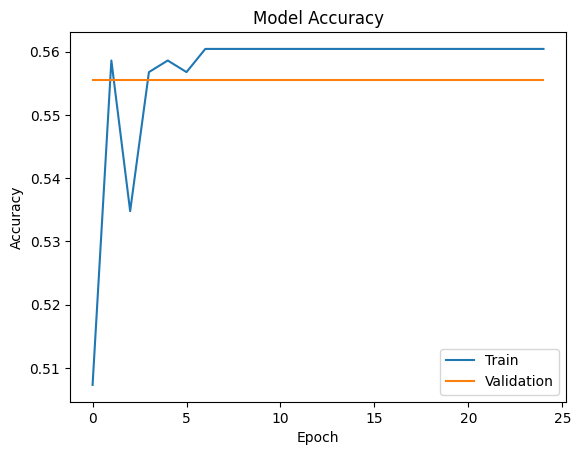

In [86]:
plt.plot(history_aug.history['accuracy'])
plt.plot(history_aug.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

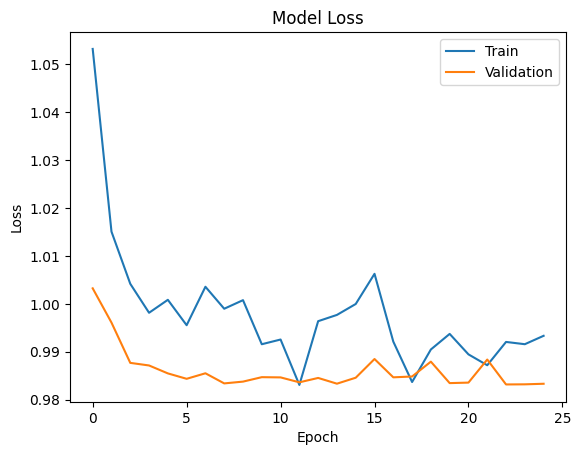

In [87]:
plt.plot(history_aug.history['loss'])
plt.plot(history_aug.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

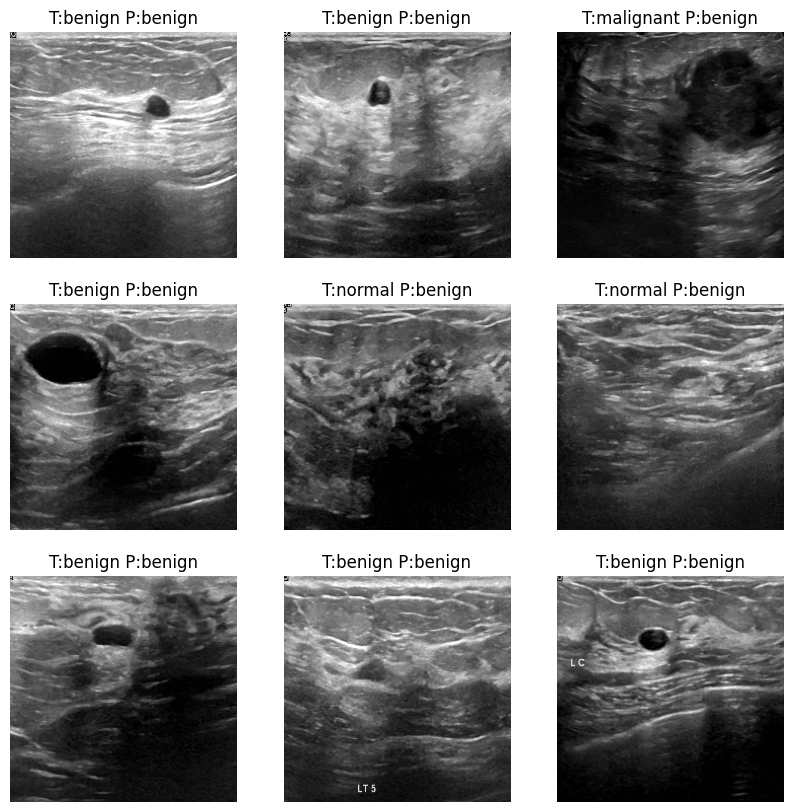

In [88]:
indices = np.random.choice(len(X_test),9)

plt.figure(figsize=(10,10))

for i,idx in enumerate(indices):

    img = X_test[idx]

    true_label = le.classes_[y_test[idx]]

    pred_label = le.classes_[pred_classes[idx]]

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(f"T:{true_label} P:{pred_label}")

    plt.axis("off")

plt.show()

In [89]:
print("\nFINAL MODEL COMPARISON")

print("\nBaseline")
print(acc1,prec1,rec1,f11)

print("\nSMOTE")
print(acc2,prec2,rec2,f12)

print("\nClass Weight")
print(acc3,prec3,rec3,f13)

print("\nAugmentation")
print(acc4,prec4,rec4,f14)


FINAL MODEL COMPARISON

Baseline
0.5641025641025641 0.31821170282708744 0.5641025641025641 0.40689365279529216

SMOTE
0.26495726495726496 0.0702023522536343 0.26495726495726496 0.11099561099561099

Class Weight
0.5641025641025641 0.31821170282708744 0.5641025641025641 0.40689365279529216

Augmentation
0.5641025641025641 0.31821170282708744 0.5641025641025641 0.40689365279529216
